In [56]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [57]:
## Cargamos los datos

data = pd.read_excel(r"employees.xlsx")

data.head()

,idempleado,Sales_€K,Customers,Training_Hours,Satisfaction,Calls_per_day
0,1,87,42,9,72,0
1,2,73,35,11,68,1
2,3,62,24,8,71,0
3,4,75,30,11,74,4
4,5,72,29,11,65,0


In [58]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 232 entries, 0 to 231
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   idempleado      232 non-null    int64
 1   Sales_€K        232 non-null    int64
 2   Customers       232 non-null    int64
 3   Training_Hours  232 non-null    int64
 4   Satisfaction    232 non-null    int64
 5   Calls_per_day   232 non-null    int64
dtypes: int64(6)
memory usage: 11.0 KB


In [59]:
# Seleccionar únicamente las columnas que me interesan para el PCA
data_pca = data[['Sales_€K',
                 'Customers',
                 'Training_Hours',
                 'Satisfaction',
                 'Calls_per_day']]

In [60]:
data_pca.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 232 entries, 0 to 231
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Sales_€K        232 non-null    int64
 1   Customers       232 non-null    int64
 2   Training_Hours  232 non-null    int64
 3   Satisfaction    232 non-null    int64
 4   Calls_per_day   232 non-null    int64
dtypes: int64(5)
memory usage: 9.2 KB


In [61]:
# Estandarizamos los datos
scaler = StandardScaler()
X = scaler.fit_transform(data_pca)

In [62]:
# Generación del modelo PCA
pca = PCA()
components = pca.fit_transform(X)

[0.417 0.345 0.192 0.028 0.018]


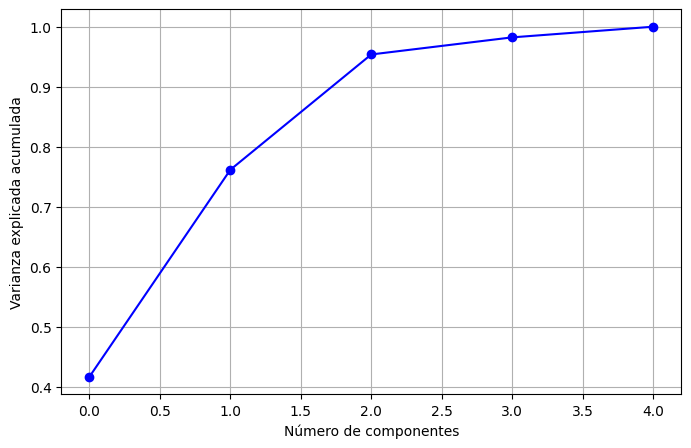

In [63]:
varianza = pca.explained_variance_ratio_
print(np.round(varianza,3))

# Visualizacion de proporcion de varianza explicada por los factores

plt.figure(figsize=(8, 5))
plt.plot(np.cumsum(varianza), marker='o', color='blue')
plt.xlabel('Número de componentes')
plt.ylabel('Varianza explicada acumulada')
plt.grid(True)
plt.show()

In [64]:
# Generacion de las componentes principales

pca = PCA(n_components=3)

X_pca = pca.fit_transform(X)

X_pca.shape

(232, 3)

In [65]:
# Matriz de cargas 

loadings = pd.DataFrame(
    pca.components_.T, 
    columns=['PC1', 'PC2', 'PC3'],
    index=data_pca.columns
)
loadings=loadings.round(3)
print(loadings)

                  PC1    PC2    PC3
Sales_€K        0.528 -0.460  0.098
Customers       0.547 -0.424  0.150
Training_Hours -0.186  0.049  0.981
Satisfaction    0.437  0.553  0.064
Calls_per_day   0.443  0.548  0.045


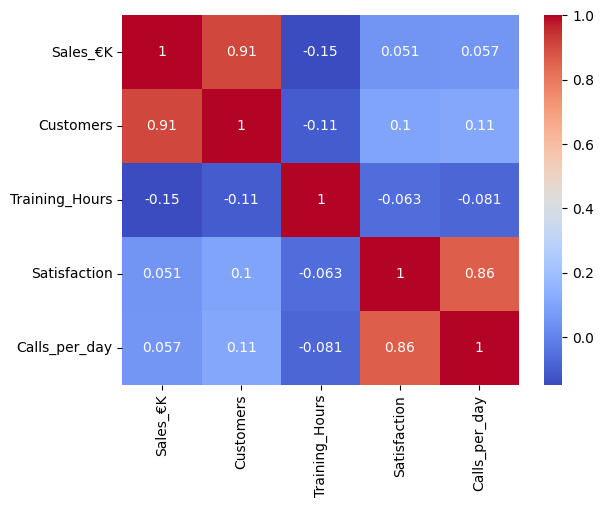

In [66]:
import seaborn as sns

# Matriz de correlación
corr = data_pca.corr()

# Heatmap
sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.show()